In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv("European_Bank.csv")

## Remove Non-informative Features

In [4]:
cols_to_drop = [col for col in ['CustomerId', 'Surname', 'Year'] if col in df.columns]
df = df.drop(columns=cols_to_drop)

In [5]:
# Handle missing values 

df = df.dropna()

## Features Engineering

In [6]:
df['Balance_To_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Product_Density'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Engagement_Product_Interaction'] = df['IsActiveMember'] * df['NumOfProducts']
df['Age_Tenure_Interaction'] = df['Age'] * (df['Tenure'] + 1)
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], labels=['Young', 'Middle_Aged', 'Senior', 'Elderly'])

In [7]:
categorical_cols = ['Geography', 'Gender', 'Age_Group']
df_encoded = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], drop_first=True)

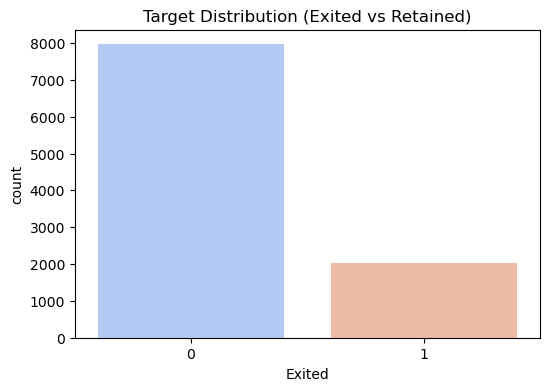

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', hue='Exited', palette='coolwarm', legend=False)
plt.title('Target Distribution (Exited vs Retained)')
plt.show()

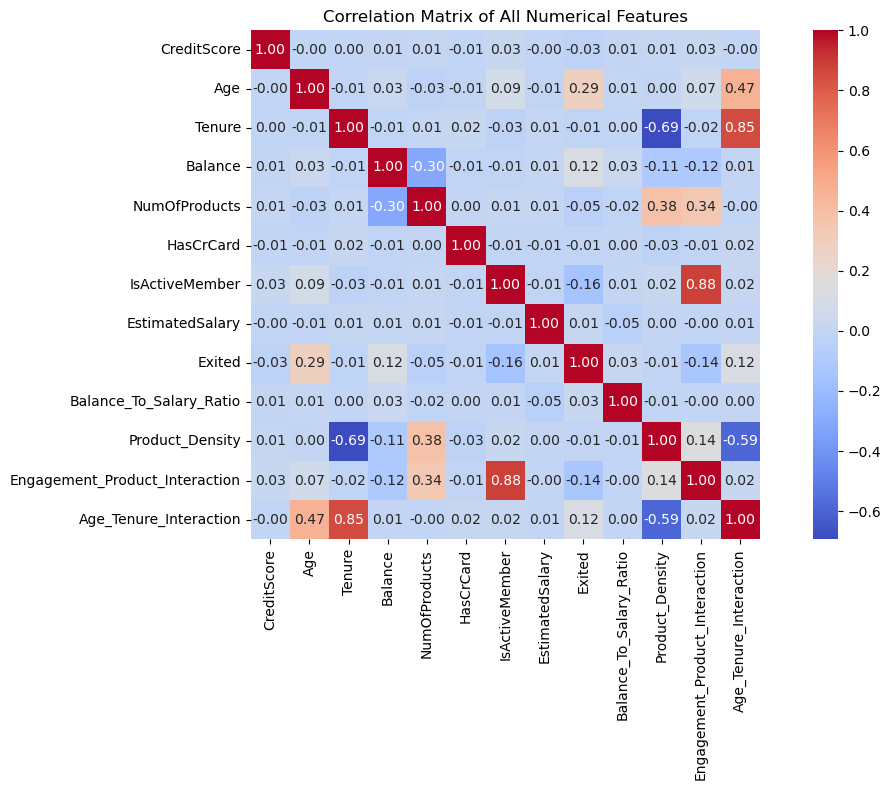

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title('Correlation Matrix of All Numerical Features')
plt.tight_layout()
plt.show()

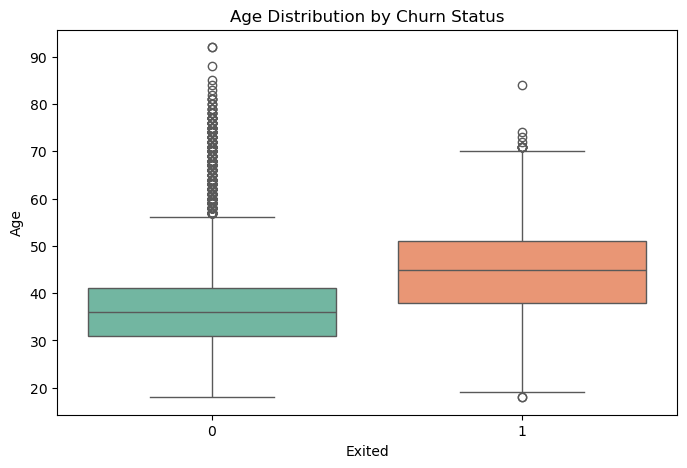

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Exited', y='Age', hue='Exited', palette='Set2', legend=False)
plt.title('Age Distribution by Churn Status')
plt.show()

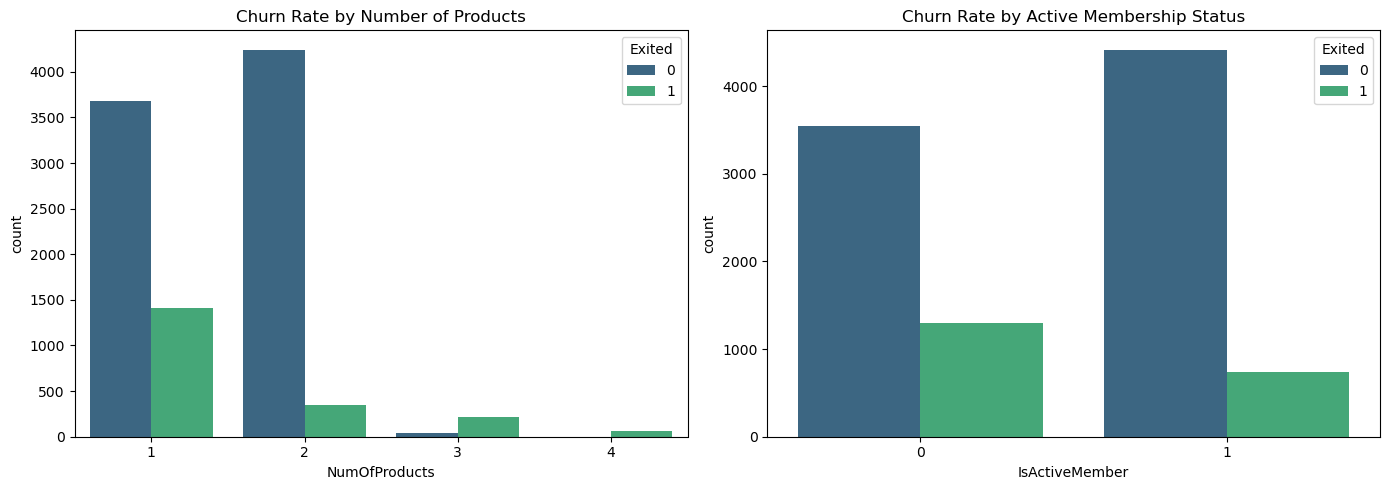

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[0], palette='viridis')
axes[0].set_title('Churn Rate by Number of Products')
sns.countplot(data=df, x='IsActiveMember', hue='Exited', ax=axes[1], palette='viridis')
axes[1].set_title('Churn Rate by Active Membership Status')
plt.tight_layout()
plt.show()

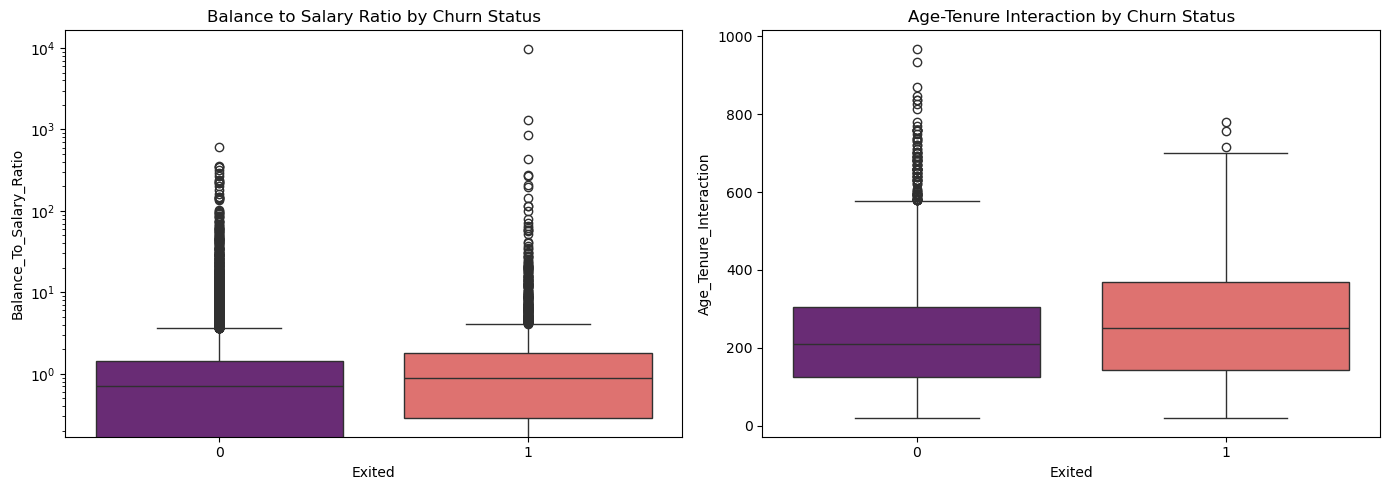

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Exited', y='Balance_To_Salary_Ratio', ax=axes[0], hue='Exited', palette='magma', legend=False)
axes[0].set_title('Balance to Salary Ratio by Churn Status')
axes[0].set_yscale('log')
sns.boxplot(data=df, x='Exited', y='Age_Tenure_Interaction', ax=axes[1], hue='Exited', palette='magma', legend=False)
axes[1].set_title('Age-Tenure Interaction by Churn Status')

plt.tight_layout()
plt.show()

## Train - Test - Split

In [13]:
X = df_encoded.drop(columns=['Exited'])
Y = df_encoded['Exited']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Development

In [20]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=6),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1),
    "XGBoost Baseline": XGBClassifier(random_state=42, eval_metric='logloss')
}

In [21]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    predictions = model.predict(X_test_scaled)
    probabilities = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(Y_test, predictions),
        "Precision": precision_score(Y_test, predictions),
        "Recall": recall_score(Y_test, predictions),
        "F1-Score": f1_score(Y_test, predictions),
        "ROC-AUC": roc_auc_score(Y_test, probabilities)
    }

In [22]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 3]  # Adjusts for data imbalance to boost Recall
}

In [25]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, Y_train)

best_xgb = grid_search.best_estimator_
xgb_tuned_preds = best_xgb.predict(X_test_scaled)
xgb_tuned_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

In [26]:
results["XGBoost (Tuned Optimization)"] = {
    "Accuracy": accuracy_score(Y_test, xgb_tuned_preds),
    "Precision": precision_score(Y_test, xgb_tuned_preds),
    "Recall": recall_score(Y_test, xgb_tuned_preds),
    "F1-Score": f1_score(Y_test, xgb_tuned_preds),
    "ROC-AUC": roc_auc_score(Y_test, xgb_tuned_probs)
}

models["XGBoost (Tuned Optimization)"] = best_xgb

## Model Evaluation

In [27]:
metrics_df = pd.DataFrame(results).T
print(metrics_df)

                              Accuracy  Precision    Recall  F1-Score  \
Logistic Regression             0.8365   0.715054  0.326781  0.448567   
Decision Tree                   0.8550   0.774648  0.405405  0.532258   
Random Forest                   0.8675   0.819820  0.447174  0.578696   
Gradient Boosting               0.8725   0.822034  0.476658  0.603421   
XGBoost Baseline                0.8470   0.675958  0.476658  0.559078   
XGBoost (Tuned Optimization)    0.8720   0.808163  0.486486  0.607362   

                               ROC-AUC  
Logistic Regression           0.790108  
Decision Tree                 0.833475  
Random Forest                 0.863310  
Gradient Boosting             0.870651  
XGBoost Baseline              0.833178  
XGBoost (Tuned Optimization)  0.868553  


## MODEL EXPLAINABILITY

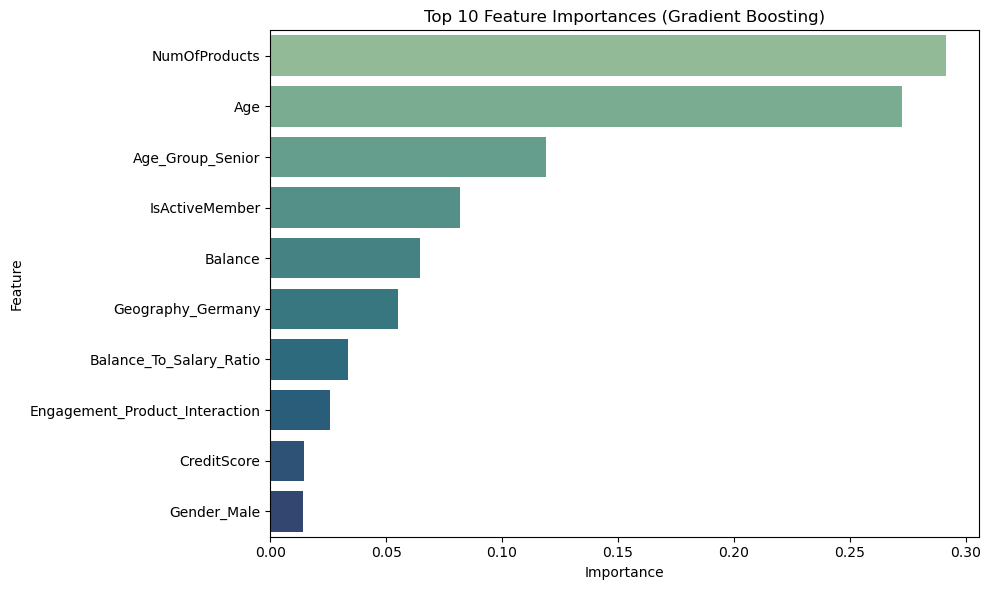

In [30]:
best_model_name = metrics_df["ROC-AUC"].idxmax()
best_model = models[best_model_name]

importances = best_model.feature_importances_ if hasattr(best_model, 'feature_importances_') else best_model.coef_[0]
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(importances)})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), hue='Feature', palette='crest', legend=False)
plt.title(f"Top 10 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()